In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.5 MB/s eta 0:00:00


In [2]:
import torch, torch_geometric
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import ConvergenceWarning

In [3]:
df_matrix = pd.read_csv("/content/drive/MyDrive/sn_data/cooperation_matrix.csv", index_col=0)

df_matrix.shape

(5246, 5246)

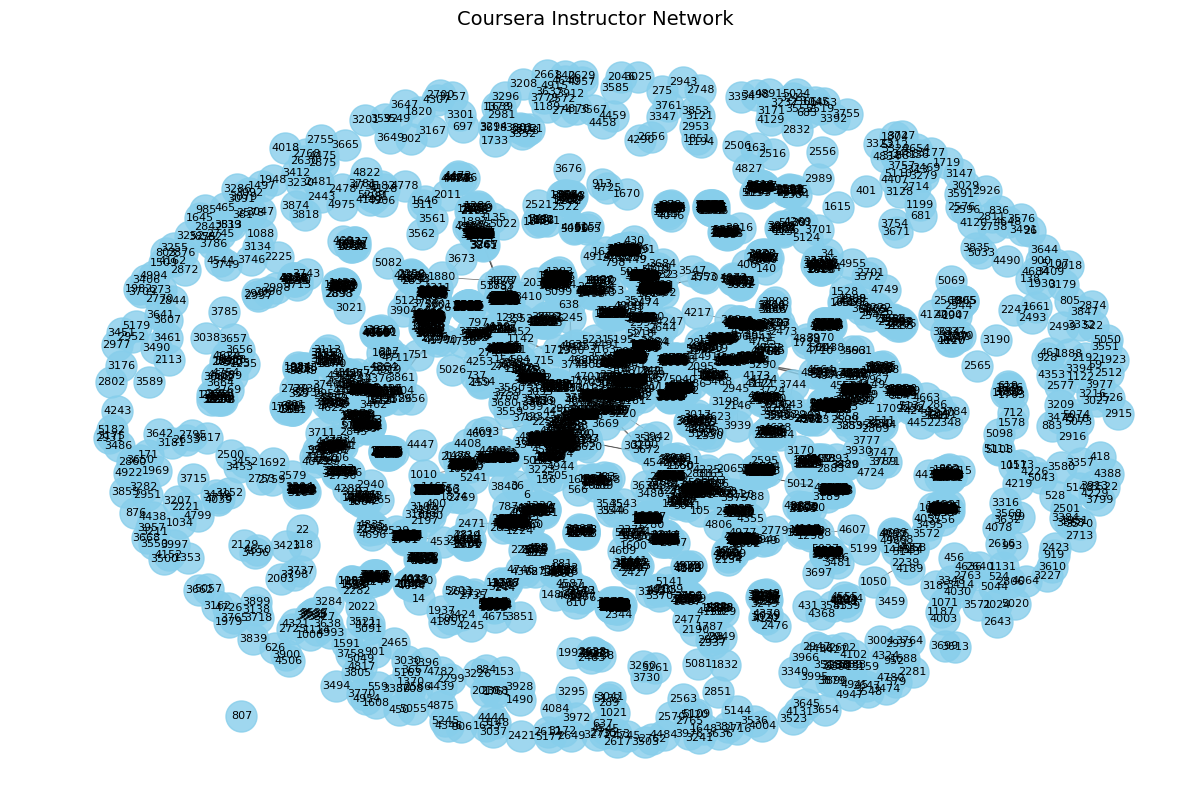

In [4]:
# Số instructor
n = df_matrix.shape[0]

# ====== Khởi tạo đồ thị ======
G = nx.Graph()

# Thêm node (theo ID, tên = ID để đơn giản, hoặc bạn có thể load từ instructors.json)
for i in range(n):
    G.add_node(i, name=str(i))

# Thêm cạnh với trọng số
for i in range(n):
    for j in range(i+1, n):
        weight = df_matrix.iloc[i, j]
        if weight > 0:
            G.add_edge(i, j, weight=weight)

# ====== Trực quan hóa mạng ======
plt.figure(figsize=(12, 8))

# Layout
pos = nx.spring_layout(G, k=0.5, seed=42)

# Vẽ node
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue", alpha=0.8)

# Vẽ cạnh (độ dày theo số lần hợp tác)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w*0.5 for w in weights], alpha=0.6)

# Vẽ nhãn (ở đây dùng ID, nếu muốn tên giảng viên thì load từ instructors.json)
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Coursera Instructor Network", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 5246
Number of edges: 139722


In [6]:
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)
pagerank_cent = nx.pagerank(G)

In [7]:
# Tìm top 3 node quan trọng nhất theo từng chỉ số
def get_top_nodes(centrality_dict, k=3):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:k]

print("\nTop 3 Degree Centrality:")
for node, score in get_top_nodes(degree_cent):
    print(f"  Node {node}: {score:.3f}")

print("\nTop 3 Betweenness Centrality:")
for node, score in get_top_nodes(betweenness_cent):
    print(f"  Node {node}: {score:.3f}")

print("\nTop 3 Closeness Centrality:")
for node, score in get_top_nodes(closeness_cent):
    print(f"  Node {node}: {score:.3f}")

print("\nTop 3 PageRank:")
for node, score in get_top_nodes(pagerank_cent):
    print(f"  Node {node}: {score:.3f}")


Top 3 Degree Centrality:
  Node 4812: 0.052
  Node 1548: 0.044
  Node 3595: 0.044

Top 3 Betweenness Centrality:
  Node 226: 0.040
  Node 2009: 0.034
  Node 4812: 0.029

Top 3 Closeness Centrality:
  Node 226: 0.081
  Node 2009: 0.079
  Node 4812: 0.073

Top 3 PageRank:
  Node 3140: 0.002
  Node 226: 0.001
  Node 4952: 0.001


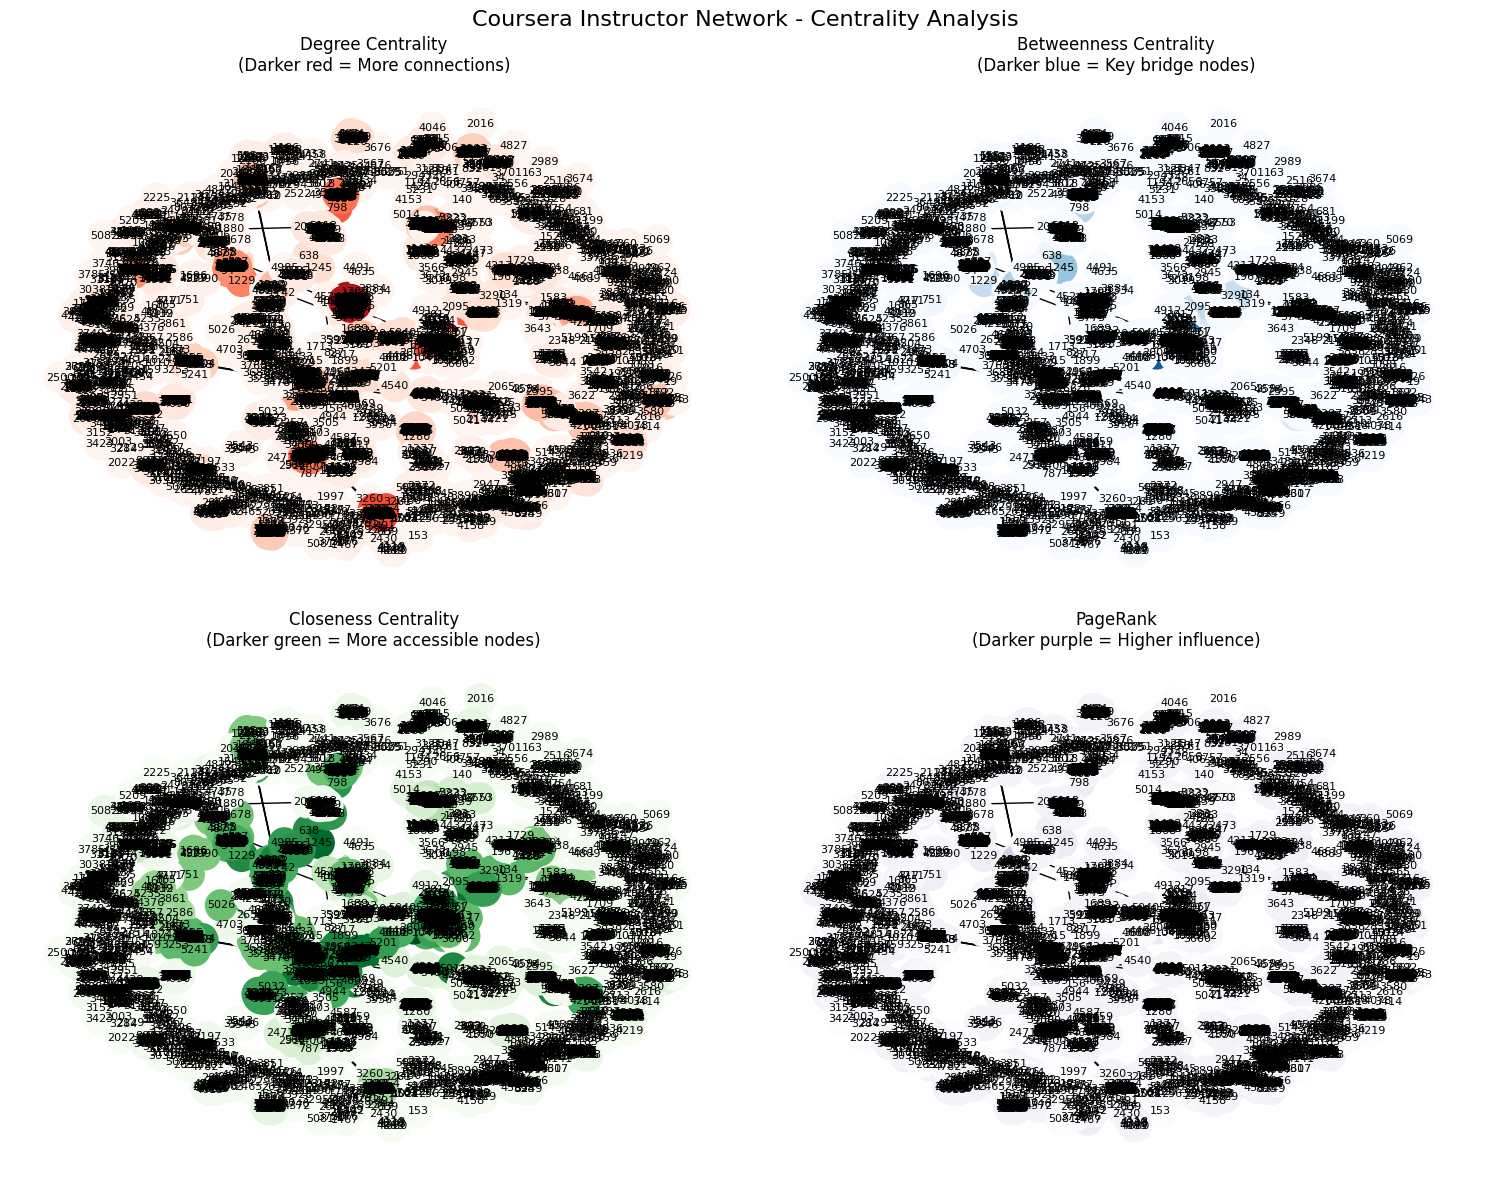

In [8]:
# Vẽ 4 biểu đồ khác nhau theo 4 chỉ số
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Coursera Instructor Network - Centrality Analysis', fontsize=16)

# Tạo layout cố định để so sánh
pos = nx.spring_layout(G, seed=42)

# 1. Degree Centrality
ax1 = axes[0, 0]
node_colors = [degree_cent[node] for node in G.nodes()]
nx.draw(G, pos, ax=ax1, node_color=node_colors, cmap='Reds',
        node_size=500, with_labels=True, font_size=8)
ax1.set_title('Degree Centrality\n(Darker red = More connections)')

# 2. Betweenness Centrality
ax2 = axes[0, 1]
node_colors = [betweenness_cent[node] for node in G.nodes()]
nx.draw(G, pos, ax=ax2, node_color=node_colors, cmap='Blues',
        node_size=500, with_labels=True, font_size=8)
ax2.set_title('Betweenness Centrality\n(Darker blue = Key bridge nodes)')

# 3. Closeness Centrality
ax3 = axes[1, 0]
node_colors = [closeness_cent[node] for node in G.nodes()]
nx.draw(G, pos, ax=ax3, node_color=node_colors, cmap='Greens',
        node_size=500, with_labels=True, font_size=8)
ax3.set_title('Closeness Centrality\n(Darker green = More accessible nodes)')

# 4. PageRank
ax4 = axes[1, 1]
node_colors = [pagerank_cent[node] for node in G.nodes()]
nx.draw(G, pos, ax=ax4, node_color=node_colors, cmap='Purples',
        node_size=500, with_labels=True, font_size=8)
ax4.set_title('PageRank\n(Darker purple = Higher influence)')

plt.tight_layout()
plt.show()

Running Girvan-Newman (one level)...
Running Louvain...
Running Label Propagation...
Running Leiden (if available)...
Skipping Leiden (leidenalg or igraph not installed).
Running Fast Greedy (if igraph available)...
Running Spectral Clustering (Normalized Cuts)...
Running Multi-level Spectral (simple coarsening)...

=== Community detection comparison ===
                               Algorithm  Num_Communities  Modularity  \
0                          Girvan-Newman              648    0.845323   
1                                Louvain              662    0.932293   
2                      Label Propagation              690    0.930717   
3  Spectral Clustering (Normalized Cuts)              238    0.052142   
4                   Multi-level Spectral               10    0.004424   

   Silhouette  NMI_vs_Org  
0    0.067482    0.765111  
1    0.324846    0.835394  
2    0.376287    0.849096  
3   -0.671641    0.347042  
4   -0.417101    0.047317  


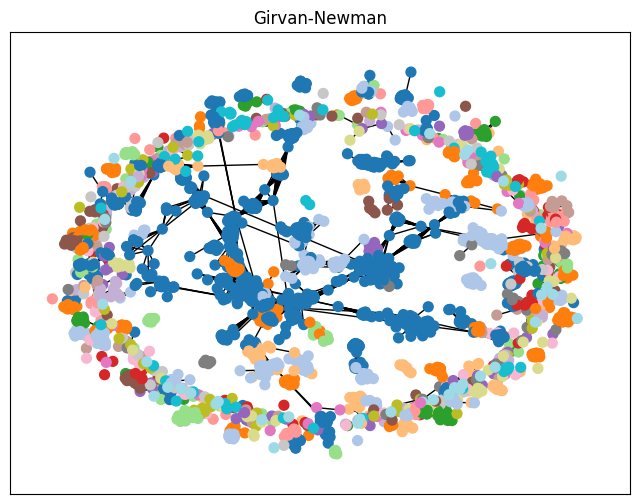

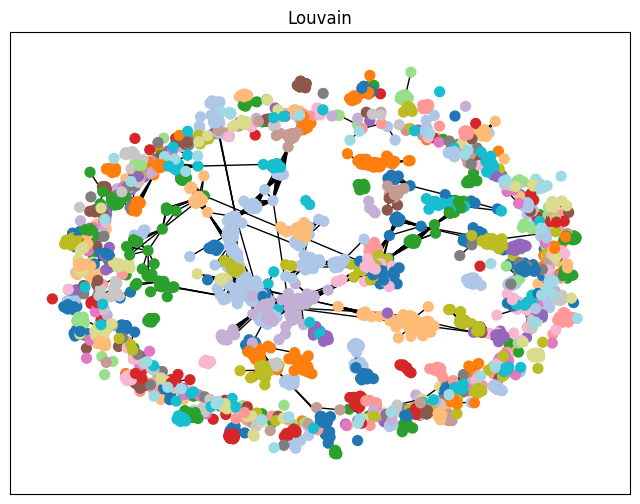

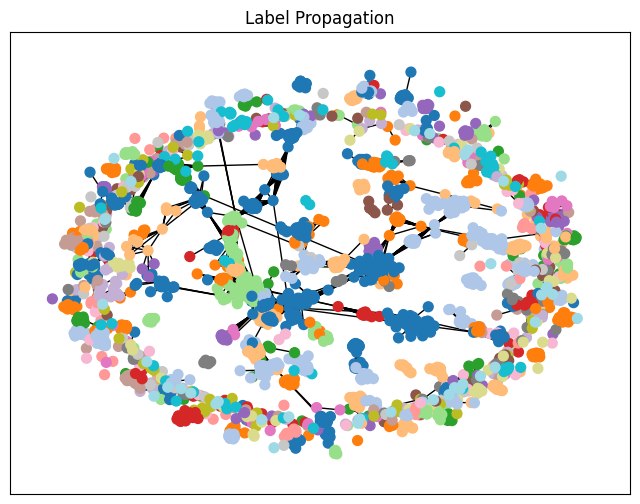

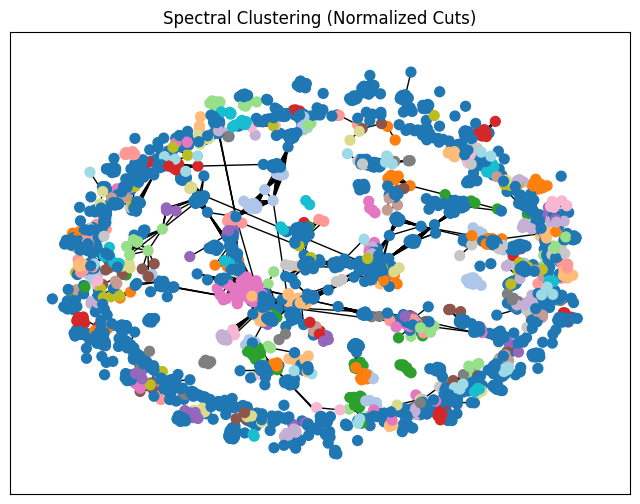

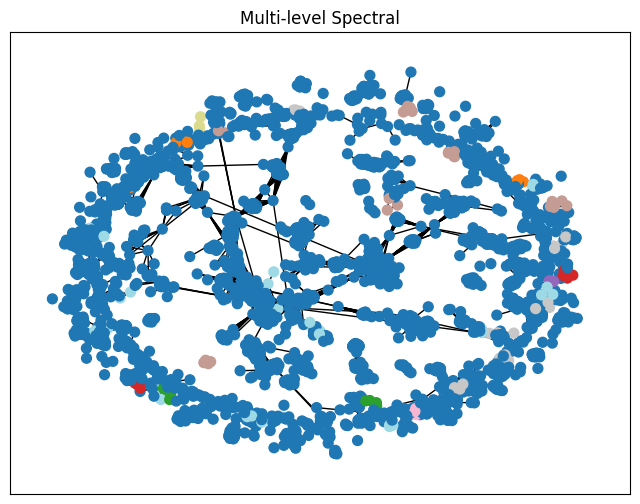

Preparing graph data for PyG on cuda
Training GCN...
Training GraphSAGE...
Training GAT...

=== GNN evaluation (NMI vs org labels) ===
       Model  NMI_vs_Org
0        GCN    0.650201
1  GraphSAGE    0.798808
2        GAT    0.711928

All done. 'results_df' contains the community detection comparison. If GNNs ran, gnn_res contains their evaluation.


In [9]:
# --- Try optional imports (with helpful messages) ---
try:
    import igraph as ig
except Exception as e:
    ig = None
    print("Warning: python-igraph not available. Fast Greedy / igraph-based methods will be skipped. Install with: pip install python-igraph")

try:
    import leidenalg as la
except Exception as e:
    la = None
    print("Warning: leidenalg not available. Leiden algorithm will be skipped. Install with: pip install leidenalg")

# PyG (PyTorch Geometric) for GNNs
try:
    import torch
    from torch import nn
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv, GATConv
except Exception as e:
    torch = None
    print("Warning: torch / torch_geometric not available. GNN models (GCN/GraphSAGE/GAT) will be skipped. Install with: pip install torch torch-geometric")

# Community algorithms from networkx
from networkx.algorithms.community import (
    girvan_newman,
    label_propagation_communities,
    modularity
)
# louvain via networkx's louvain_communities if available (NetworkX >= 2.8) or python-louvain fallback
try:
    from networkx.algorithms.community import louvain_communities
except Exception:
    try:
        import community as community_louvain
        louvain_communities = None
    except Exception:
        louvain_communities = None
        community_louvain = None
        print("Warning: Louvain not available. Install python-louvain or upgrade networkx.")

# ------------------ Load data ------------------
# You must provide df_matrix (pandas DataFrame) and instructors_all.json path.
# The original code assumed df_matrix exists. If not, load it here.
# Example: df_matrix = pd.read_csv("cooperation_matrix.csv", index_col=0)
# For demo, we'll assume df_matrix is present in the environment.

try:
    df_matrix
except NameError:
    raise RuntimeError("df_matrix is not defined in the environment. Load your cooperation matrix into a pandas DataFrame named df_matrix before running this script.")

with open("/content/drive/MyDrive/sn_data/instructors_all.json", "r", encoding="utf-8") as f:
    instructors = json.load(f)

instructors_dict = {ins["id"]: ins for ins in instructors}
n = df_matrix.shape[0]

# ------------------ Build graph ------------------
G = nx.Graph()
for i in range(n):
    ins_info = instructors_dict.get(i, {})
    G.add_node(i,
               ins_name=ins_info.get("ins_name", str(i)),
               organizations=ins_info.get("organizations", []))

for i in range(n):
    for j in range(i+1, n):
        weight = df_matrix.iloc[i, j]
        if weight > 0:
            G.add_edge(i, j, weight=float(weight))

# Ground-truth labels from organization (first organization if present)
org_labels = []
for node in G.nodes():
    orgs = G.nodes[node]["organizations"]
    if not orgs:
        org_labels.append("Unknown")
    else:
        org_labels.append(orgs[0])
le_org = LabelEncoder()
y_org = le_org.fit_transform(org_labels)  # numeric labels for NMI / GNN supervision

# Helper: compute metrics safely
def safe_metrics(communities, G, X_pos):
    """Given communities (list of sets), return num_comms, modularity, silhouette (or nan), nmi (w/ org_labels)"""
    if communities is None or len(communities) == 0:
        return 0, np.nan, np.nan, np.nan
    # labels per node in node order
    node2comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
    labels = [node2comm.get(node, -1) for node in G.nodes()]
    # modularity
    try:
        Q = modularity(G, communities)
    except Exception:
        Q = np.nan
    # silhouette: need >=2 clusters and X_pos defined
    sil = np.nan
    try:
        if len(set(labels)) >= 2:
            sil = silhouette_score(X_pos, labels)
    except Exception:
        sil = np.nan
    # NMI vs org
    try:
        nmi = normalized_mutual_info_score(y_org, labels)
    except Exception:
        nmi = np.nan
    return len(communities), Q, sil, nmi

# Precompute 2D embedding from spring layout for silhouette (can be replaced by spectral embedding)
pos = nx.spring_layout(G, seed=42)
X = np.array([pos[node] for node in G.nodes()])

# ------------------ 1) Girvan-Newman ------------------
print("Running Girvan-Newman (one level)...")
try:
    comp_gn = girvan_newman(G)
    communities_gn = tuple(sorted(c) for c in next(comp_gn))
except Exception as e:
    communities_gn = []
    print("Girvan-Newman failed:", e)

# ------------------ 2) Louvain ------------------
print("Running Louvain...")
if louvain_communities is not None:
    try:
        communities_lv = louvain_communities(G, weight="weight", seed=42)
    except Exception as e:
        communities_lv = []
        print("NetworkX louvain_communities failed:", e)
else:
    # fallback to python-louvain
    if community_louvain is not None:
        part = community_louvain.best_partition(G, weight="weight")
        # convert partition dict -> list of sets
        comm_map = {}
        for node, cid in part.items():
            comm_map.setdefault(cid, set()).add(node)
        communities_lv = [sorted(list(s)) for s in comm_map.values()]
    else:
        communities_lv = []
        print("Louvain is unavailable in this environment.")

# ------------------ 3) Label Propagation ------------------
print("Running Label Propagation...")
try:
    communities_lp = list(label_propagation_communities(G))
except Exception as e:
    communities_lp = []
    print("Label Propagation failed:", e)

# ------------------ 4) Leiden (if available) ------------------
print("Running Leiden (if available)...")
communities_leiden = []
if la is not None and ig is not None:
    try:
        # Convert to igraph
        # Build ig.Graph from networkx
        g_igraph = ig.Graph.TupleList(G.edges(), directed=False)
        partition = la.find_partition(g_igraph, la.ModularityVertexPartition, weights=[G[u][v].get('weight',1.0) for u,v in g_igraph.get_edgelist()])
        communities_leiden = [list(c) for c in partition]
    except Exception as e:
        print("Leiden failed:", e)
else:
    print("Skipping Leiden (leidenalg or igraph not installed).")

# ------------------ 5) Fast Greedy (igraph) ------------------
print("Running Fast Greedy (if igraph available)...")
communities_fastgreedy = []
if ig is not None:
    try:
        g_igraph = ig.Graph.TupleList(G.edges(), directed=False)
        # if weights exist, make sure igraph has them
        if any('weight' in G[u][v] for u, v in G.edges()):
            weights = [G[u][v].get('weight', 1.0) for u, v in g_igraph.get_edgelist()]
            g_igraph.es['weight'] = weights
            dendro = g_igraph.community_fastgreedy(weights=g_igraph.es['weight'])
        else:
            dendro = g_igraph.community_fastgreedy()
        clusters = dendro.as_clustering()
        communities_fastgreedy = [list(c) for c in clusters]
    except Exception as e:
        print("Fast Greedy failed:", e)

# ------------------ 6) Spectral Clustering (normalized cuts) ------------------
print("Running Spectral Clustering (Normalized Cuts)...")
# choose k = number of ground-truth org labels unique (or fallback to 8)
k_guess = max(2, len(set(y_org)))
try:
    # affinity = adjacency matrix (dense)
    A = nx.to_numpy_array(G, weight='weight')
    sc = SpectralClustering(n_clusters=k_guess, affinity='precomputed', assign_labels='kmeans', random_state=42)
    labels_sc = sc.fit_predict(A)
    # convert labels -> communities
    comm_map = {}
    for node_index, lab in enumerate(labels_sc):
        comm_map.setdefault(int(lab), []).append(node_index)
    communities_spectral = list(comm_map.values())
except Exception as e:
    print("Spectral Clustering failed:", e)
    communities_spectral = []

# ------------------ 7) Multi-level Spectral (simple coarsen-refine) ------------------
print("Running Multi-level Spectral (simple coarsening)...")
def heavy_edge_matching_coarsen(A, levels=1):
    """A: adjacency matrix np.array; simple heavy-edge matching coarsening"""
    n = A.shape[0]
    matched = np.full(n, False)
    mapping = np.arange(n)
    new_nodes = []
    for i in range(n):
        if matched[i]:
            continue
        # find neighbour with max weight
        neighbours = np.where(A[i] > 0)[0]
        candidate = None
        maxw = 0
        for j in neighbours:
            if not matched[j] and A[i,j] > maxw:
                candidate = j
                maxw = A[i,j]
        if candidate is None:
            new_nodes.append([i])
            matched[i] = True
        else:
            new_nodes.append([i, candidate])
            matched[i] = matched[candidate] = True
    # build coarse adjacency
    m = len(new_nodes)
    Acoarse = np.zeros((m,m))
    for u in range(m):
        for v in range(m):
            for i in new_nodes[u]:
                for j in new_nodes[v]:
                    Acoarse[u,v] += A[i,j]
    return Acoarse, new_nodes

try:
    A = nx.to_numpy_array(G, weight='weight')
    Acoarse, groups = heavy_edge_matching_coarsen(A, levels=1)
    # spectral on coarse
    k_coarse = max(2, min(10, len(groups)))
    sc2 = SpectralClustering(n_clusters=k_coarse, affinity='precomputed', assign_labels='kmeans', random_state=42)
    labels_coarse = sc2.fit_predict(Acoarse)
    # refine labels back to original nodes
    communities_multispec = [[] for _ in range(k_coarse)]
    for coarse_idx, nodes_in_group in enumerate(groups):
        lab = labels_coarse[coarse_idx]
        for orig_node in nodes_in_group:
            communities_multispec[lab].append(orig_node)
except Exception as e:
    print("Multi-level Spectral failed:", e)
    communities_multispec = []

# ------------------ Evaluate and collect results ------------------
algorithms = []
communities_list = []

algorithms.append("Girvan-Newman")
communities_list.append(communities_gn)

algorithms.append("Louvain")
communities_list.append(communities_lv)

algorithms.append("Label Propagation")
communities_list.append(communities_lp)

if communities_leiden:
    algorithms.append("Leiden")
    communities_list.append(communities_leiden)

if communities_fastgreedy:
    algorithms.append("Fast Greedy (igraph)")
    communities_list.append(communities_fastgreedy)

algorithms.append("Spectral Clustering (Normalized Cuts)")
communities_list.append(communities_spectral)

if communities_multispec:
    algorithms.append("Multi-level Spectral")
    communities_list.append(communities_multispec)

# Compute metrics table
rows = []
for name, comms in zip(algorithms, communities_list):
    num_comms, Q, sil, nmi = safe_metrics(comms, G, X)
    rows.append({
        "Algorithm": name,
        "Num_Communities": num_comms,
        "Modularity": Q,
        "Silhouette": sil,
        "NMI_vs_Org": nmi
    })

results_df = pd.DataFrame(rows)
print("\n=== Community detection comparison ===")
print(results_df)

# ------------------ Optional: visualize communities (simple) ------------------
def plot_communities(G, communities, title=None):
    color_map = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            color_map[node] = idx
    colors = [color_map.get(node, -1) for node in G.nodes()]
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G, pos=pos, node_color=colors, with_labels=False, node_size=50, cmap='tab20')
    if title:
        plt.title(title)
    plt.show()

# Example plots for top 3 algorithms
for name, comms in zip(algorithms, communities_list):
    if comms:
        plot_communities(G, comms, title=name)

# ------------------ GNNs: GCN, GraphSAGE, GAT (node classification) ------------------
if torch is not None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Preparing graph data for PyG on", device)

    # Prepare edge_index
    edge_index = np.array(list(G.edges())).T  # shape (2, m)
    if edge_index.size == 0:
        raise RuntimeError("Graph has no edges; cannot train GNNs.")

    # PyG expects edge_index as [2, num_edges] with ints
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    # add reverse edges
    edge_index = torch.cat([edge_index, edge_index[[1,0]]], dim=1)

    # Node features: we can use simple features (degree, clustering, one-hot id is too large)
    deg = np.array([d for _, d in G.degree()])
    deg = deg.reshape(-1,1).astype(float)
    # optionally concentate normalized centrality
    try:
        bc = np.array(list(nx.betweenness_centrality(G).values())).reshape(-1,1)
    except Exception:
        bc = np.zeros_like(deg)
    X_feat = np.hstack([deg, bc])
    x = torch.tensor(X_feat, dtype=torch.float)

    y = torch.tensor(y_org, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y).to(device)

    # train/test split (semi-supervised)
    num_nodes = data.num_nodes
    np.random.seed(42)
    perm = np.random.permutation(num_nodes)
    n_train = max(5, int(0.1 * num_nodes))  # at least small set
    train_idx = torch.tensor(perm[:n_train], dtype=torch.long).to(device)
    test_idx = torch.tensor(perm[n_train:], dtype=torch.long).to(device)

    # helper train loop
    def train_gnn(model, optimizer, epochs=200):
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            out = model(data.x, data.edge_index)
            loss = nn.CrossEntropyLoss()(out[train_idx], data.y[train_idx])
            loss.backward()
            optimizer.step()
        # evaluate
        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            preds = logits.argmax(dim=1).cpu().numpy()
        return preds

    # GCN
    class SimpleGCN(nn.Module):
        def __init__(self, in_feats, hid=32, out_feats=None):
            super().__init__()
            self.conv1 = GCNConv(in_feats, hid)
            self.conv2 = GCNConv(hid, out_feats)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            x = self.conv2(x, edge_index)
            return x

    # GraphSAGE
    class SimpleSAGE(nn.Module):
        def __init__(self, in_feats, hid=32, out_feats=None):
            super().__init__()
            self.conv1 = SAGEConv(in_feats, hid)
            self.conv2 = SAGEConv(hid, out_feats)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            x = self.conv2(x, edge_index)
            return x

    # GAT
    class SimpleGAT(nn.Module):
        def __init__(self, in_feats, hid=32, out_feats=None, heads=4):
            super().__init__()
            self.conv1 = GATConv(in_feats, hid, heads=heads)
            self.conv2 = GATConv(hid*heads, out_feats, heads=1)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            x = self.conv2(x, edge_index)
            return x

    out_dim = int(y.max().item()) + 1
    in_dim = data.num_node_features

    # Train GCN
    print("Training GCN...")
    gcn = SimpleGCN(in_dim, hid=64, out_feats=out_dim).to(device)
    opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
    preds_gcn = train_gnn(gcn, opt, epochs=200)

    # Train GraphSAGE
    print("Training GraphSAGE...")
    sage = SimpleSAGE(in_dim, hid=64, out_feats=out_dim).to(device)
    opt2 = torch.optim.Adam(sage.parameters(), lr=0.01, weight_decay=5e-4)
    preds_sage = train_gnn(sage, opt2, epochs=200)

    # Train GAT
    print("Training GAT...")
    gat = SimpleGAT(in_dim, hid=32, out_feats=out_dim, heads=4).to(device)
    opt3 = torch.optim.Adam(gat.parameters(), lr=0.005, weight_decay=5e-4)
    preds_gat = train_gnn(gat, opt3, epochs=300)

    # Evaluate GNNs: compute NMI between predictions and org labels as a proxy
    from sklearn.metrics import normalized_mutual_info_score
    nmi_gcn = normalized_mutual_info_score(y.cpu().numpy(), preds_gcn)
    nmi_sage = normalized_mutual_info_score(y.cpu().numpy(), preds_sage)
    nmi_gat = normalized_mutual_info_score(y.cpu().numpy(), preds_gat)

    gnn_res = pd.DataFrame({
        "Model": ["GCN", "GraphSAGE", "GAT"],
        "NMI_vs_Org": [nmi_gcn, nmi_sage, nmi_gat]
    })
    print("\n=== GNN evaluation (NMI vs org labels) ===")
    print(gnn_res)
else:
    print("Skipping GNN training because torch/torch_geometric is not installed.")

# ------------------ Done ------------------
print("\nAll done. 'results_df' contains the community detection comparison. If GNNs ran, gnn_res contains their evaluation.")


In [10]:
results_df

,Algorithm,Num_Communities,Modularity,Silhouette,NMI_vs_Org
0,Girvan-Newman,648,0.845323,0.067482,0.765111
1,Louvain,662,0.932293,0.324846,0.835394
2,Label Propagation,690,0.930717,0.376287,0.849096
3,Spectral Clustering (Normalized Cuts),238,0.052142,-0.671641,0.347042
4,Multi-level Spectral,10,0.004424,-0.417101,0.047317



=== Ensemble Graph (Louvain + Label Propagation) ===
Consensus graph has 5246 nodes and 139442 edges

=== Ensemble Graph Evaluation ===
Num_Communities: 666
Modularity: 0.9321
Silhouette: 0.3523
NMI_vs_Org: 0.8419


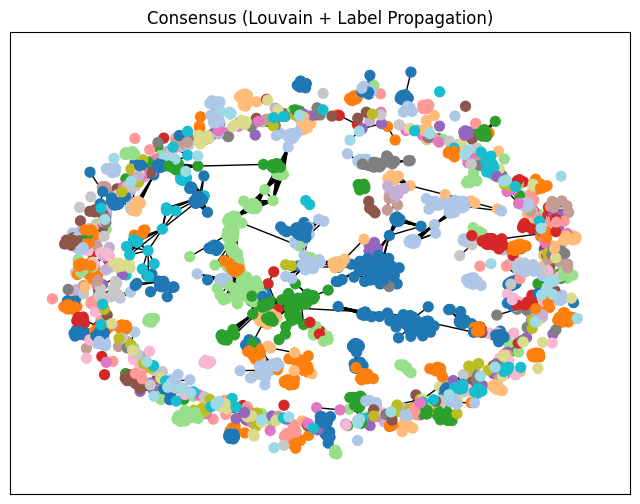

In [11]:
# ===========================================================
#    ENSEMBLE GRAPH: Louvain + Label Propagation Consensus
# ===========================================================
print("\n=== Ensemble Graph (Louvain + Label Propagation) ===")

# 1️⃣ Lấy nhãn cộng đồng từ Louvain và LP
def get_labels_from_communities(communities, n_nodes):
    """Convert list of sets -> label array"""
    node2comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
    labels = np.array([node2comm.get(i, -1) for i in range(n_nodes)])
    return labels

labels_lv = get_labels_from_communities(communities_lv, G.number_of_nodes())
labels_lp = get_labels_from_communities(communities_lp, G.number_of_nodes())

# 2️⃣ Xây đồ thị đồng thuận (đảm bảo có đủ node)
G_cons = nx.Graph()
G_cons.add_nodes_from(G.nodes())  # Giữ toàn bộ node

for u, v in G.edges():
    agree = 0
    if labels_lv[u] == labels_lv[v]:
        agree += 1
    if labels_lp[u] == labels_lp[v]:
        agree += 1
    if agree > 0:
        G_cons.add_edge(u, v, weight=agree / 2.0)

print(f"Consensus graph has {G_cons.number_of_nodes()} nodes and {G_cons.number_of_edges()} edges")

# 3️⃣ Chạy Louvain trên đồ thị đồng thuận
try:
    communities_cons = louvain_communities(G_cons, weight="weight", seed=42)
except Exception as e:
    print("Louvain consensus failed:", e)
    communities_cons = []

# 4️⃣ Tính chỉ số đánh giá
def safe_metrics(communities, G, X, y_org):
    if not communities:
        return np.nan, np.nan, np.nan
    node2comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
    labels = [node2comm.get(node, -1) for node in G.nodes()]
    try:
        Q = modularity(G, communities)
    except Exception:
        Q = np.nan
    try:
        sil = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
    except Exception:
        sil = np.nan
    try:
        nmi = normalized_mutual_info_score(y_org, labels)
    except Exception:
        nmi = np.nan
    return Q, sil, nmi

Q_ens, sil_ens, nmi_ens = safe_metrics(communities_cons, G, X, y_org)

print("\n=== Ensemble Graph Evaluation ===")
print(f"Num_Communities: {len(communities_cons)}")
print(f"Modularity: {Q_ens:.4f}")
print(f"Silhouette: {sil_ens:.4f}")
print(f"NMI_vs_Org: {nmi_ens:.4f}")

# 5️⃣ Vẽ biểu đồ
def plot_communities(G, communities, pos, title=None):
    color_map = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            color_map[node] = idx
    colors = [color_map.get(node, -1) for node in G.nodes()]
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G, pos=pos, node_color=colors, with_labels=False,
                     node_size=50, cmap="tab20")
    if title:
        plt.title(title)
    plt.show()

plot_communities(G_cons, communities_cons, pos, title="Consensus (Louvain + Label Propagation)")


=== Hybrid: Label Propagation (graph) + Label Propagation (GAT embeddings) ===
Original Label Propagation: 690 communities (unique labels ignoring -1)
Reusing existing 'gat' model.
Embedding-sim graph: nodes=5246, edges=43247 (top-10 NN)
Label Propagation on embedding-sim graph: 144 communities
Consensus graph (LP + LP_on_GAT) has 5246 nodes and 139028 edges
Final consensus (LP+GAT) communities: 693

=== Summary ===
Original Label Propagation: {'Num_Communities': 690, 'Modularity': 0.9307174687150808, 'Silhouette': np.float64(0.3762865203538255), 'NMI_vs_Org': np.float64(0.849095663615792)}
Label Propagation on GAT-embedding: {'Num_Communities': 144, 'Modularity': 0.7700767878370971, 'Silhouette': np.float64(0.023423685203138995), 'NMI_vs_Org': np.float64(0.8602790443793144)}
Consensus (LP + LP_on_GAT): {'Num_Communities': 693, 'Modularity': 0.9307908482534665, 'Silhouette': np.float64(0.39975436668814845), 'NMI_vs_Org': np.float64(0.8511958631106918)}


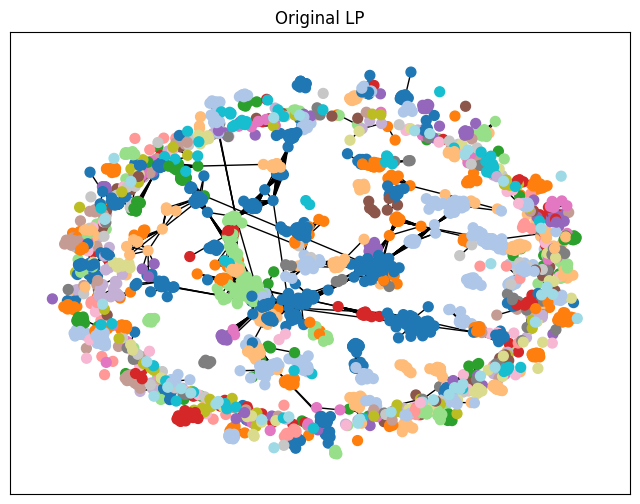

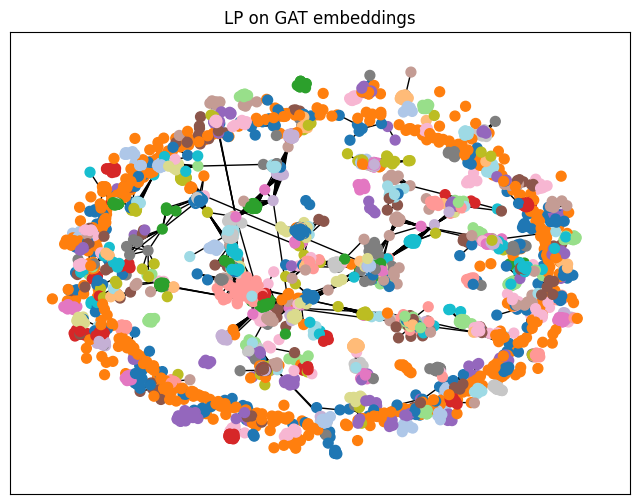

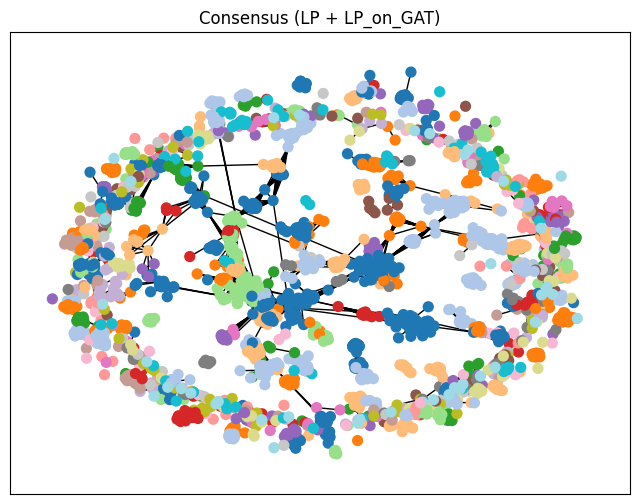

In [12]:
# ------------------ Hybrid: Label Propagation (original) + Label Propagation on GAT-embedding ------------------
print("\n=== Hybrid: Label Propagation (graph) + Label Propagation (GAT embeddings) ===")

from sklearn.metrics.pairwise import normalize as sk_normalize
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import label_propagation_communities
from networkx.algorithms.community import modularity
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
import math

# PARAMETERS
TOP_K = 10        # number of nearest neighbours to keep per node in sim graph (tweak for memory/speed)
EMBED_LAYER = 'conv1'  # which layer output of GAT to use as embedding

N = G.number_of_nodes()

# 1) Ensure we have original Label Propagation labels (labels_lp)
# If labels_lp not present, compute it:
if 'labels_lp' not in globals():
    try:
        communities_lp = list(label_propagation_communities(G))
        def get_labels_from_communities(communities, n_nodes):
            node2comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
            return np.array([node2comm.get(i, -1) for i in range(n_nodes)])
        labels_lp = get_labels_from_communities(communities_lp, N)
    except Exception as e:
        raise RuntimeError("Could not compute label propagation on original graph: " + str(e))

num_comms_lp = len(set(labels_lp[labels_lp >= 0]))
print(f"Original Label Propagation: {num_comms_lp} communities (unique labels ignoring -1)")

# 2) Obtain or train a GAT to get embeddings
if torch is None:
    raise RuntimeError("Torch / torch_geometric not installed; cannot run GAT hybrid.")

# reuse existing 'gat' if present and trained; otherwise train a small one
gat_model = None
if 'gat' in globals():
    gat_model = gat
    print("Reusing existing 'gat' model.")
else:
    print("Training a small GAT (for embeddings)...")
    gat_model = SimpleGAT(in_dim, hid=32, out_feats=out_dim, heads=4).to(device)
    opt_tmp = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
    # quick training (use available labels y if you have them; else use pseudo y_org)
    sup_y = data.y if hasattr(data, 'y') else torch.tensor(y_org, dtype=torch.long).to(device)
    epochs_quick = 150
    for epoch in range(epochs_quick):
        gat_model.train()
        opt_tmp.zero_grad()
        out_logits = gat_model(data.x, data.edge_index)
        loss_tmp = nn.CrossEntropyLoss()(out_logits[train_idx], sup_y[train_idx])
        loss_tmp.backward()
        opt_tmp.step()
    print("GAT training (quick) done.")

# 3) Extract embeddings (use conv1 output to get smoother embeddings)
gat_model.eval()
with torch.no_grad():
    # If model has attribute conv1, use it; else run forward and take output
    try:
        embed_tensor = gat_model.conv1(data.x, data.edge_index)
    except Exception:
        emb_out = gat_model(data.x, data.edge_index)
        embed_tensor = emb_out
    Z_gat = embed_tensor.cpu().numpy()  # shape (N, d)

# 4) Build sparse similarity graph from embeddings using top-k neighbors
# Normalize embeddings row-wise for cosine similarity
Z_norm = sk_normalize(Z_gat, norm='l2')
# We'll compute top-k per row without building full NxN matrix
rows = []
cols = []
weights = []

for i in range(N):
    vi = Z_norm[i]  # 1 x d
    # compute cosine similarities row-wise (dot with all rows)
    sims = Z_norm.dot(vi)  # length N
    sims[i] = -1.0  # exclude self
    # get top-k indices
    k = min(TOP_K, N-1)
    if k <= 0:
        continue
    topk_idx = np.argpartition(-sims, k-1)[:k]  # unsorted topk
    for j in topk_idx:
        simval = float(sims[j])
        if simval <= 0:
            continue
        rows.append(i)
        cols.append(j)
        weights.append(simval)

# build sim graph as undirected by adding symmetric edges (take max weight if duplicate)
G_sim = nx.Graph()
G_sim.add_nodes_from(G.nodes())  # keep all nodes
for u, v, w in zip(rows, cols, weights):
    if G_sim.has_edge(u, v):
        # keep max weight
        if G_sim[u][v].get('weight', 0) < w:
            G_sim[u][v]['weight'] = w
    else:
        G_sim.add_edge(u, v, weight=w)

# Make sure graph is undirected symmetric: add reverse edges where necessary (nx.Graph is undirected)
print(f"Embedding-sim graph: nodes={G_sim.number_of_nodes()}, edges={G_sim.number_of_edges()} (top-{TOP_K} NN)")

# 5) Run Label Propagation on sim graph
try:
    communities_lp_on_emb = list(label_propagation_communities(G_sim))
    labels_lp_on_emb = get_labels_from_communities(communities_lp_on_emb, N)
    num_comms_lp_emb = len([c for c in set(labels_lp_on_emb) if c >= 0])
    print(f"Label Propagation on embedding-sim graph: {num_comms_lp_emb} communities")
except Exception as e:
    print("Label Propagation on sim graph failed:", e)
    communities_lp_on_emb = []
    labels_lp_on_emb = np.full(N, -1, dtype=int)

# 6) Build consensus graph between labels_lp (original LP) and labels_lp_on_emb
G_cons = nx.Graph()
G_cons.add_nodes_from(G.nodes())  # keep all nodes

for u, v, d in G.edges(data=True):
    agree = 0
    # if both methods say same community for this edge's endpoints
    if labels_lp[u] == labels_lp[v] and labels_lp[u] != -1:
        agree += 1
    if labels_lp_on_emb[u] == labels_lp_on_emb[v] and labels_lp_on_emb[u] != -1:
        agree += 1
    if agree > 0:
        G_cons.add_edge(u, v, weight=agree / 2.0)

print(f"Consensus graph (LP + LP_on_GAT) has {G_cons.number_of_nodes()} nodes and {G_cons.number_of_edges()} edges")

# 7) Run Label Propagation on consensus graph to get final consensus labels
try:
    communities_consensus = list(label_propagation_communities(G_cons))
    labels_consensus = get_labels_from_communities(communities_consensus, N)
    num_comms_consensus = len([c for c in set(labels_consensus) if c >= 0])
    print(f"Final consensus (LP+GAT) communities: {num_comms_consensus}")
except Exception as e:
    print("Label Propagation on consensus graph failed:", e)
    communities_consensus = []
    labels_consensus = np.full(N, -1, dtype=int)
    num_comms_consensus = 0

# 8) Evaluate results (Modularity, Silhouette, NMI) using safe_metrics-like logic
def evaluate_communities(communities, G_ref, X_pos, y_org):
    if not communities:
        return {"Num_Communities": 0, "Modularity": np.nan, "Silhouette": np.nan, "NMI_vs_Org": np.nan}
    node2comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
    labels = [node2comm.get(node, -1) for node in G_ref.nodes()]
    try:
        Q = modularity(G_ref, communities)
    except Exception:
        Q = np.nan
    try:
        sil = silhouette_score(X_pos, labels) if len(set(labels)) > 1 else np.nan
    except Exception:
        sil = np.nan
    try:
        nmi = normalized_mutual_info_score(y_org, labels)
    except Exception:
        nmi = np.nan
    return {"Num_Communities": len(communities), "Modularity": Q, "Silhouette": sil, "NMI_vs_Org": nmi}

res_lp = evaluate_communities(communities_lp, G, X, y_org)
res_lp_emb = evaluate_communities(communities_lp_on_emb, G, X, y_org)
res_cons = evaluate_communities(communities_consensus, G, X, y_org)

print("\n=== Summary ===")
print("Original Label Propagation:", res_lp)
print("Label Propagation on GAT-embedding:", res_lp_emb)
print("Consensus (LP + LP_on_GAT):", res_cons)

# 9) Visualize final consensus communities (if any)
def plot_comms_from_parts(G_ref, parts, pos, title):
    if not parts:
        print("No communities to plot for", title)
        return
    color_map = {}
    for idx, comm in enumerate(parts):
        for node in comm:
            color_map[node] = idx
    colors = [color_map.get(node, -1) for node in G_ref.nodes()]
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G_ref, pos=pos, node_color=colors, with_labels=False, node_size=50, cmap='tab20')
    plt.title(title)
    plt.show()

plot_comms_from_parts(G, communities_lp, pos, title="Original LP")
plot_comms_from_parts(G, communities_lp_on_emb, pos, title="LP on GAT embeddings")
plot_comms_from_parts(G, communities_consensus, pos, title="Consensus (LP + LP_on_GAT)")

In [13]:
summary_data = [
    ["Label Propagation (original)",
     res_lp["Num_Communities"],
     res_lp["Modularity"],
     res_lp["Silhouette"],
     res_lp["NMI_vs_Org"]],

    ["Label Propagation (GAT embedding)",
     res_lp_emb["Num_Communities"],
     res_lp_emb["Modularity"],
     res_lp_emb["Silhouette"],
     res_lp_emb["NMI_vs_Org"]],

    ["Consensus (LP + LP_on_GAT)",
     res_cons["Num_Communities"],
     res_cons["Modularity"],
     res_cons["Silhouette"],
     res_cons["NMI_vs_Org"]],
]

df_summary = pd.DataFrame(
    summary_data,
    columns=["Algorithm", "Communities", "Modularity", "Silhouette", "NMI"]
)

print(df_summary.to_string(index=False,
                           justify="center",
                           formatters={
                               "Modularity": "{:.3f}".format,
                               "Silhouette": "{:.3f}".format,
                               "NMI": "{:.3f}".format
                           }))

            Algorithm              Communities Modularity Silhouette  NMI 
     Label Propagation (original)     690        0.931      0.376    0.849
Label Propagation (GAT embedding)     144        0.770      0.023    0.860
       Consensus (LP + LP_on_GAT)     693        0.931      0.400    0.851
